In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

sys.path.append("..")
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

INFO:Constants:Logging to file: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Code/Python/pyBayerSMLM/logs/Constants_20251121_150252.log
/tmp/ipykernel_177023/2105147448.py:33: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter()


# Refactored Code Example Using New Interface

This section demonstrates how to run the same 3-camera comparison using the new refactored `test_simulation_method()` interface with proper parameter validation and configuration management.

In [2]:
# Import the new refactored classes
from src.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'demosaic', 'demosaic_fast', 'demosaic_ig']


In [3]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [4]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()

cameras = ["Camera_Bayer", "Camera_Sharp", "Camera_Standard"]

R_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
G_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)
B_nonsharp = np.max(G) * gaussian_model(wavelength, 650, 500)

R_sharp = copy(R)
G_sharp = copy(G)
B_sharp = copy(B)
B_sharp[wavelength < 500] = np.max(G)
B_sharp[wavelength >= 500] = 0
G_sharp[(wavelength < 500) | (wavelength > 600)] = 0
G_sharp[(wavelength < 600) & (wavelength >= 500)] = np.max(G)
R_sharp[wavelength < 600] = 0
R_sharp[wavelength >= 600] = np.max(G)

wavelength = wavelength
pixel_QYs_normal = np.vstack([B, G, R])
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])
pixel_QYs_sharp = np.vstack([B_sharp, G_sharp, R_sharp])

In [5]:
# Setup camera parameters using the new validation system
cameras_refactored = ["Camera_Bayer", "Camera_Sharp", "Camera_Standard"]
pixel_QYs_list = [pixel_QYs_normal, pixel_QYs_sharp, pixel_QYs_broad]

# Validate and create CameraParameters dataclasses for each camera type
validated_camera_parameters = {}

for i, camera in enumerate(cameras_refactored):
    camera_parameters_dict = {
        "gain": np.full((image_size, image_size), np.median(gain)),
        "offset": np.full((image_size, image_size), np.median(offset)),
        "variance": np.full((image_size, image_size), np.median(variance)),
        "readnoise": np.full((image_size, image_size), np.median(readnoise)),
        "rqe": np.full((image_size, image_size), np.median(rqe)),
        "masks": masks,
        "pixel_QYs": pixel_QYs_list[i],
        "pixel_order": ["B", "G", "R"],
        "pixel_order_indices": {
            "B": 0,
            "G": 1,
            "R": 2,
        },  # Fixed to use dict instead of list
    }

    try:
        # Validate camera parameters using new dataclass
        validated_camera_parameters[camera] = CameraParameters.validate_and_create(
            camera_parameters_dict
        )
        print(f"✅ {camera} parameters validated successfully")
    except Exception as e:
        print(f"❌ {camera} validation failed: {e}")

print(f"\nValidated {len(validated_camera_parameters)} camera configurations")

✅ Camera_Bayer parameters validated successfully
✅ Camera_Sharp parameters validated successfully
✅ Camera_Standard parameters validated successfully

Validated 3 camera configurations


In [6]:
# Create simulation configuration using the new dataclass
config_refactored = SimulationConfig(
    n_bootstrap=100000,  # Reduced for faster testing - increase to 100000 for full run
    background_photons=40.0,
    background_colour=[1, 1, 1],
    NA=1.49,
    pixel_size=69,
    cpu_fraction=0.9,
    save_raw_results=True,
    subtractx0y0=False,  # Important for position accuracy analysis
    saverawimages=False,
    verbose=False,
)

print("Simulation configuration created:")
print(f"  Bootstrap samples: {config_refactored.n_bootstrap}")
print(f"  Background photons: {config_refactored.background_photons}")
print(f"  Numerical aperture: {config_refactored.NA}")
print(f"  Pixel size: {config_refactored.pixel_size} nm")
print(f"  Save raw results: {config_refactored.save_raw_results}")
print(f"  Subtract ground truth positions: {config_refactored.subtractx0y0}")

Simulation configuration created:
  Bootstrap samples: 100000
  Background photons: 40.0
  Numerical aperture: 1.49
  Pixel size: 69 nm
  Save raw results: True
  Subtract ground truth positions: False


In [7]:
# Setup save folder for refactored results
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Results will be saved to: {save_folder_refactored}")

# Reduced photon space and dye list for testing
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]

notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
nilered_filter = "semrock-ff01-650-200-25"
shortpass_filter = "semrock-bsp01-785r"
filters = [dichroic_mirror, shortpass_filter, notch_filter]

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

print(f"Testing with photon levels: {n_photon_space}")
print(f"Testing with dyes: {dyes}")

Results will be saved to: /home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored
Testing with photon levels: [   500.    510.    525.    535.    550.    560.    575.    590.    600.
    615.    630.    645.    660.    675.    690.    705.    725.    740.
    760.    775.    795.    815.    830.    850.    870.    890.    915.
    935.    955.    980.   1000.   1025.   1050.   1075.   1100.   1125.
   1150.   1175.   1205.   1235.   1260.   1290.   1320.   1350.   1385.
   1415.   1450.   1485.   1520.   1555.   1590.   1630.   1665.   1705.
   1745.   1785.   1825.   1870.   1915.   1960.   2005.   2050.   2100.
   2150.   2200.   2250.   2305.   2355.   2410.   2470.   2525.   2585.
   2645.   2710.   2770.   2835.   2905.   2970.   3040.   3110.   3185.
   3260.   3335.   3415.   3495.   3575.   3660.   3745.   3830.   3920.
   4015.   4105.   4205.   4300.   4400.   4505.   4610.   4720.   4830.
   4940.   5060.   5175.   5300.   5420.   5550.   

In [ ]:
# Run simulations using the new refactored interface
print("Running simulations with new refactored interface...")
print("=" * 60)

for i, dye in enumerate(dyes):
    for camera in cameras_refactored:
        print(f"🔬 Analyzing {dye} with {camera}...")

        try:
            # Convert validated dataclass back to dict for compatibility
            camera_params_dict = validated_camera_parameters[camera].__dict__.copy()

            # Use the new unified method with STANDARD strategy (equivalent to old test_fit_method)
            MSF.test_simulation_method(
                dye=dye,
                filters=filters,
                wavelength=wavelength,
                camera_parameters=camera_params_dict,
                save_folder=save_folder_refactored,
                n_photon_space=n_photon_space,  # Using test range
                smoothing_function=smoothing_function,
                strategy=FittingStrategy.STANDARD,  # New strategy enum
                starting_flag=f"refactored_3cameras_{camera}_",
                config=config_refactored,  # New config dataclass
                overwrite=False
            )
            print(f"✅ Completed {dye} with {camera}")

        except Exception as e:
            print(f"❌ Failed {dye} with {camera}: {str(e)}")

print("\\n🎉 Refactored simulations completed!")
print(f"📁 Check results in: {save_folder_refactored}")

Running simulations with new refactored interface...
🔬 Analyzing ATTO 488 with Camera_Bayer...
Analysed photon flux 200/200    Time elapsed: 643.023 min                       ?, ?it/s]
Completed analysis of 200 photon flux values    Total time: 643.023 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


✅ Completed ATTO 488 with Camera_Bayer
🔬 Analyzing ATTO 488 with Camera_Sharp...
Analysed photon flux 200/200    Time elapsed: 639.373 min                       ?, ?it/s]
Completed analysis of 200 photon flux values    Total time: 639.373 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


✅ Completed ATTO 488 with Camera_Sharp
🔬 Analyzing ATTO 488 with Camera_Standard...
Analysed photon flux 200/200    Time elapsed: 640.229 min                       ?, ?it/s]
Completed analysis of 200 photon flux values    Total time: 640.229 min


...

✅ Completed ATTO 565 with Camera_Bayer
🔬 Analyzing ATTO 565 with Camera_Sharp...
Analysed photon flux 200/200    Time elapsed: 658.099 min                       ?, ?it/s]
Completed analysis of 200 photon flux values    Total time: 658.099 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


✅ Completed ATTO 565 with Camera_Sharp
🔬 Analyzing ATTO 565 with Camera_Standard...
Analysed photon flux 200/200    Time elapsed: 656.096 min                       ?, ?it/s]
Completed analysis of 200 photon flux values    Total time: 656.096 min


INFO:src.Multicolour_Simulation_Functions:Simulation completed for strategy standard


✅ Completed ATTO 565 with Camera_Standard
🔬 Analyzing ATTO 647N with Camera_Bayer...


In [5]:
def euclidean_distance(ground_truth_points, fitted_points):
    """
    Calculates the minimum Euclidean distance from each fitted point to any ground truth point.

    This is appropriate for localization precision analysis where the number of
    fitted points may differ from the number of ground truth points.

    Args:
      ground_truth_points: A NumPy array of shape (n, 2) representing ground truth positions.
      fitted_points: A NumPy array of shape (m, 2) representing fitted positions.

    Returns:
      A NumPy array of shape (m,) containing the minimum distance from each fitted
      point to any ground truth point.
    """
    # Ensure both arrays are 2D
    ground_truth_points = np.atleast_2d(ground_truth_points)
    fitted_points = np.atleast_2d(fitted_points)

    # Calculate distance matrix and return minimum distance for each fitted point
    distance_matrix = np.linalg.norm(ground_truth_points - fitted_points, axis=1)
    return distance_matrix

In [6]:
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored"
all_files = os.listdir(save_folder_refactored)
cameras = ["Camera_Bayer", "Camera_Sharp", "Camera_Standard"]
labels = ["Bayer", "Sharp", "Standard"]
parameters = ["xy", "colour"]
n_photon_space = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)
dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]

In [17]:
Overall_XR = xr.DataArray(
    data=np.zeros([len(cameras), len(dyes), len(n_photon_space), len(parameters)]),
    coords=[labels, dyes, n_photon_space, parameters],
    dims=["Camera_Type", "Dye", "Photon", "Analysis_Parameter"],
)
for i, camera in enumerate(cameras):
    loop_files = np.sort([x for x in all_files if camera in x])
    for j, dye in enumerate(dyes):
        dye_file = np.sort(
            [os.path.join(save_folder_refactored, x) for x in loop_files if dye in x]
        )
        dye_file_raw = np.sort([x for x in dye_file if "rawresults" in x])
        dye_xy_gt = pd.read_csv(np.sort([x for x in dye_file if "groundtruth" in x])[0])
        dye_x0 = dye_xy_gt["x0"].to_numpy() / 69
        dye_y0 = dye_xy_gt["y0"].to_numpy() / 69
        x0y0 = np.vstack(
            [
                dye_x0,
                dye_y0,
            ]
        ).T
        dye_BGR = pd.read_csv(
            np.sort([x for x in dye_file if "input_parameters" in x])[0]
        ).to_numpy()[0][-3:]
        dye_BGR = dye_BGR / np.sum(dye_BGR)
        overall_results = pd.read_hdf(os.path.join(save_folder_refactored, dye_file_raw[0]))
        print(dye_file_raw[0])
        for k, photonval in enumerate(n_photon_space):
            results = overall_results[overall_results.photon_level == k]
            filter = ~(
                (results["xc"] < 0)
                | (results["yc"] < 0)
                | (results["s_x"] < 0)
                | (results["s_y"] < 0)
                | (results["xc"] > 14)
                | (results["yc"] > 14)
            )
            if (100000 - sum(filter)) > 0:
                print(
                    "For {} at {}, {} points were removed.".format(
                        camera, photonval, 100000 - sum(filter)
                    )
                )
            XY = np.vstack(
                [
                    results["xc"].to_numpy()[filter],
                    results["yc"].to_numpy()[filter],
                ]
            ).T
            spatial_distances = euclidean_distance(x0y0[filter], XY)
            colour_loc = np.expand_dims(dye_BGR, 0)
            colour = np.vstack(
                [
                    results["A_B"].to_numpy()[filter],
                    results["A_G"].to_numpy()[filter],
                    results["A_R"].to_numpy()[filter],
                ]
            ).T
            colour_distances = cdist(colour, colour_loc)
            Overall_XR[i, j, k, 0] = np.nanstd(spatial_distances) * 69
            Overall_XR[i, j, k, 1] = np.nanstd(colour_distances)

Overall_XR.to_netcdf(os.path.join(save_folder_refactored, "3Camera_Database_STDEV.nc"))

/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Bayer_LM_method_ATTO 488_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Bayer_LM_method_ATTO 565_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Bayer_LM_method_ATTO 647N_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Sharp_LM_method_ATTO 488_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Sharp_LM_method_ATTO 565_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored/refactored_3cameras_Camera_Sharp_LM_method_ATTO 647N_rawresults.h5
/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Dat

In [ ]:
save_folder_refactored = r"/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250815_3Cameras_Refactored"
all_files = os.listdir(save_folder_refactored)
files_to_delete = np.sort(
    [
        os.path.join(save_folder_refactored, x)
        for x in all_files
        if "rawresults.csv" in x
    ]
)
for file in files_to_delete:
    os.remove(file)

In [ ]:
Overall_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "3Camera_Database_STDEV.nc")
)

In [ ]:
colour_distances

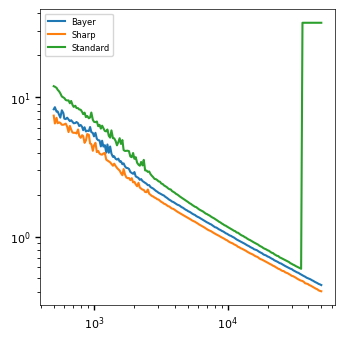

In [20]:
plt.plot(n_photon_space, Overall_XR[0, 0, :, 0], label="Bayer")
plt.plot(n_photon_space, Overall_XR[1, 0, :, 0], label="Sharp")
plt.plot(n_photon_space, Overall_XR[2, 0, :, 0], label="Standard")
plt.yscale("log")
plt.xscale("log")
plt.legend(loc="best")

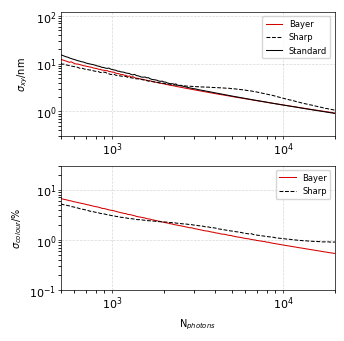

In [23]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 1], height=3.3)

axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[0, :, :, 0], axis=0),
    label="Bayer",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$",
    color="#d40000",
)

axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[1, :, :, 0], axis=0),
    label="Sharp",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$",
    color="black",
    ls="--",
)


axs[0] = plotter.line_plot(
    axs[0],
    n_photon_space,
    np.mean(Overall_XR[2, :, :, 0], axis=0),
    label="Standard",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{xy}$/nm",
)

axs[0].set_yscale("log")
axs[0].set_xscale("log")
axs[0].set_xlabel("")
axs[0].set_xlim([500, 20000])
axs[0].set_ylim([0.3, 120])
axs[0].legend(loc="best", fontsize=6)


axs[1] = plotter.line_plot(
    axs[1],
    n_photon_space,
    100 * np.mean(Overall_XR[0, :, :, 1], axis=0),
    label="Bayer",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$",
    color="#d40000",
)

axs[1] = plotter.line_plot(
    axs[1],
    n_photon_space,
    100 * np.mean(Overall_XR[1, :, :, 1], axis=0),
    label="Sharp",
    xaxislabel=r"N$_{photons}$",
    yaxislabel=r"$\sigma_{colour}$/%",
    color="black",
    ls="--",
)


axs[1].set_yscale("log")
axs[1].set_xscale("log")
axs[1].set_ylim([100 * 1e-3, 100 * 0.3])
axs[1].set_xlim([500, 20000])

fig_savefolder = (
    "/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1/"
)
# plt.savefig(os.path.join(fig_savefolder, 'Simulation_Precisions.svg'), dpi=600, format='svg')
plt.show()